# Notebook 4 — TimeGAN Training

## Objective

Train a TimeGAN (Yoon et al., NeurIPS 2019) on `models/theft_sequences.npy`
(the minority "theft" class from the SGCC dataset, produced by Notebook 3)
and generate 35,142 synthetic theft sequences for Notebook 5.

This notebook is intentionally thin: all model code lives in
`src/timegan/` (`dataset.py`, `models.py`, `losses.py`, `trainer.py`,
`generate.py`). The notebook only wires those modules together.

### Two data notes carried over from Notebook 3

1. **Out-of-range values.** Notebook 3's `MinMaxScaler` is fit on the
   *honest* population and only `.transform()`-ed on the theft population.
   A small number of theft sequences (~1.5%) therefore contain values
   above 1 (up to ~459). Every TimeGAN network here ends in a sigmoid, as
   in the original paper, which assumes `[0, 1]`-bounded data — so
   `dataset.py` clips to `[0, 1]` at load time and reports how much was
   affected. This notebook does not modify Notebook 3.
2. **Sequence length.** At `T = 1033` timesteps, these sequences are far
   longer than the paper's original benchmarks (`T ≈ 24`). The GRU stacks
   below will be noticeably slower to train and may need more Phase 3
   epochs than the paper's reported numbers to converge — a GPU runtime is
   strongly recommended.

## Cell 1 — Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Make src/ importable (notebook lives in notebooks/, src/ is a sibling of it).
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from timegan.dataset import load_sequences, make_dataset
from timegan.trainer import TimeGAN, TimeGANConfig
from timegan.generate import generate_synthetic_sequences, save_synthetic_sequences

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow: 2.21.0
Keras: 3.15.0
GPU available: False


## Cell 2 — Load `theft_sequences.npy`

In [2]:
DATA_PATH = PROJECT_ROOT / "models" / "theft_sequences.npy"

theft_data, stats = load_sequences(DATA_PATH, clip_to_unit_interval=True)

print(stats)
print("Loaded shape:", theft_data.shape, theft_data.dtype)
print("Range after clipping:", theft_data.min(), "-", theft_data.max())

SEQ_LEN = theft_data.shape[1]
FEATURE_DIM = theft_data.shape[2]
N_REAL = theft_data.shape[0]

SequenceStats(num_sequences=3615, seq_len=1033, feature_dim=1, num_points_clipped=6659, num_sequences_clipped=54, raw_min=0.0, raw_max=459.24003923666845)
Loaded shape: (3615, 1033, 1) float32
Range after clipping: 0.0 - 1.0


## Cell 3 — Create `tf.data.Dataset`

In [3]:
BATCH_SIZE = 32

train_dataset = make_dataset(
    theft_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    drop_remainder=True,
)

for batch in train_dataset.take(1):
    print("Example batch shape:", batch.shape, batch.dtype)

Example batch shape: (32, 1033, 1) <dtype: 'float32'>


## Cell 4 — Initialize TimeGAN

In [ ]:
config = TimeGANConfig(
    feature_dim=FEATURE_DIM,
    seq_len=SEQ_LEN,
    hidden_dim=64,
    num_layers=3,
    gamma=1.0,
    supervised_weight=100.0,
    moment_weight=100.0,
    embedder_supervised_weight=0.1,
    discriminator_loss_threshold=0.15,
    learning_rate=1e-3,
)


model = TimeGAN(config, seed=42)
print(config)

TimeGANConfig(feature_dim=1, seq_len=1033, hidden_dim=32, num_layers=3, z_dim=1, gamma=1.0, supervised_weight=100.0, moment_weight=100.0, embedder_supervised_weight=0.1, discriminator_loss_threshold=0.15, learning_rate=0.001)


## Cell 5 — Train model

Runs all three TimeGAN phases in sequence:
1. Embedder + Recovery pretraining (reconstruction)
2. Supervisor pretraining (next-step latent dynamics)
3. Joint adversarial training (Generator, Supervisor, Embedder, Discriminator)

Epoch counts below are reasonable starting points for `T = 1033`; increase
`phase3_epochs` if `g_loss`/`d_loss` haven't stabilized.

In [ ]:
history = model.fit(
    train_dataset,
    batch_size=BATCH_SIZE,
    phase1_epochs=100,
    phase2_epochs=100,
    phase3_epochs=500,
    verbose=1,
)

[Phase 1 | Embedder] epoch 1/2 - reconstruction_loss=0.013453
[Phase 1 | Embedder] epoch 2/2 - reconstruction_loss=0.003330
[Phase 2 | Supervisor] epoch 1/2 - supervised_loss=0.019996
[Phase 2 | Supervisor] epoch 2/2 - supervised_loss=0.000270
[Phase 3 | Joint] epoch 1/5 - g_loss=10.3480 d_loss=2.1952 e_loss=0.2358
[Phase 3 | Joint] epoch 2/5 - g_loss=7.9403 d_loss=1.8636 e_loss=0.1034
[Phase 3 | Joint] epoch 3/5 - g_loss=8.1651 d_loss=1.7800 e_loss=0.1244
[Phase 3 | Joint] epoch 4/5 - g_loss=8.2924 d_loss=1.8820 e_loss=0.1387
[Phase 3 | Joint] epoch 5/5 - g_loss=8.8979 d_loss=1.8244 e_loss=0.1576


In [6]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPUs: []


## Cell 6 — Plot losses

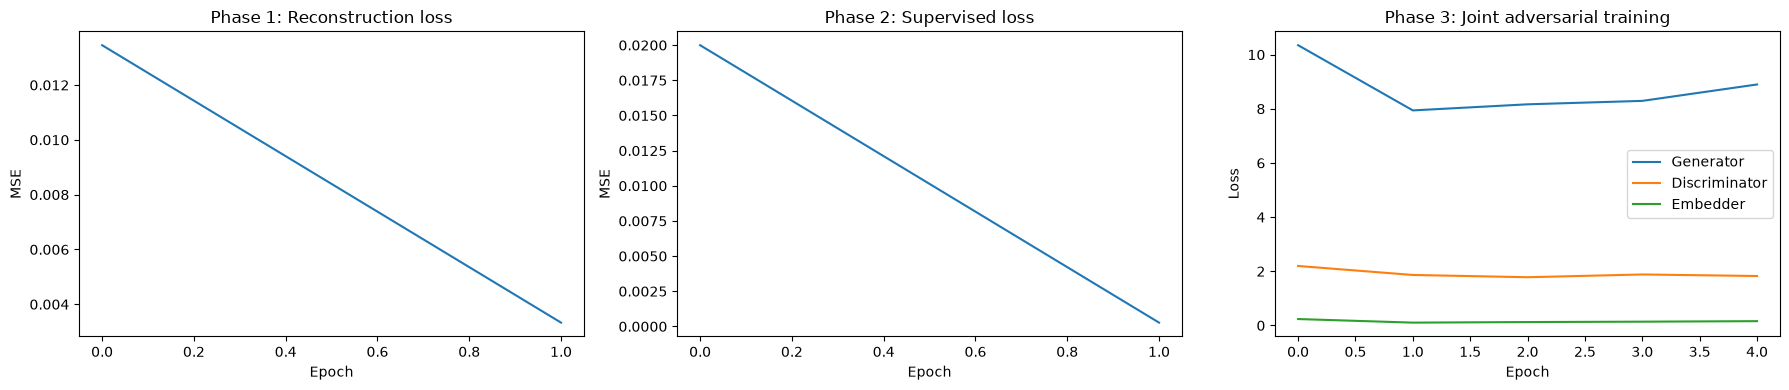

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history["phase1_reconstruction_loss"])
axes[0].set_title("Phase 1: Reconstruction loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")

axes[1].plot(history["phase2_supervised_loss"])
axes[1].set_title("Phase 2: Supervised loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE")

axes[2].plot(history["phase3_generator_loss"], label="Generator")
axes[2].plot(history["phase3_discriminator_loss"], label="Discriminator")
axes[2].plot(history["phase3_embedder_loss"], label="Embedder")
axes[2].set_title("Phase 3: Joint adversarial training")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

## Cell 7 — Generate 35,142 synthetic theft sequences

Synthetic shape: (100, 1033, 1)
Range: 0.0022234519 - 0.6907641


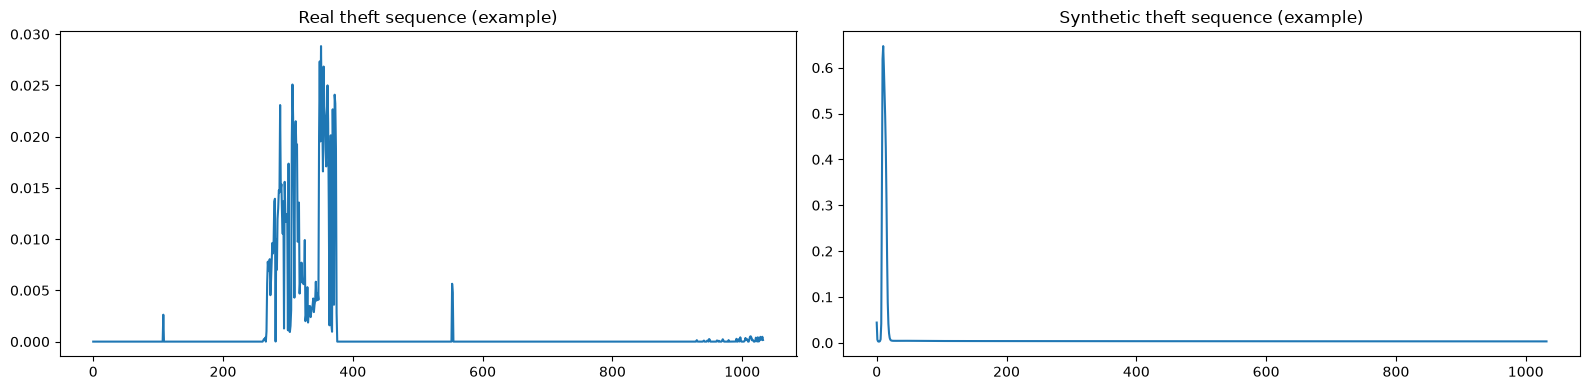

In [ ]:
N_SYNTHETIC = 35142

synthetic_theft_sequences = generate_synthetic_sequences(
    model, num_samples=N_SYNTHETIC, batch_size=64
)

print("Synthetic shape:", synthetic_theft_sequences.shape)
print("Range:", synthetic_theft_sequences.min(), "-", synthetic_theft_sequences.max())

# Quick visual sanity check: one real vs. one synthetic sequence.
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(theft_data[0, :, 0])
axes[0].set_title("Real theft sequence (example)")
axes[1].plot(synthetic_theft_sequences[0, :, 0])
axes[1].set_title("Synthetic theft sequence (example)")
plt.tight_layout()
plt.show()

## Cell 8 — Save `synthetic_theft_sequences.npy`

In [ ]:
OUTPUT_PATH = PROJECT_ROOT / "models" / "synthetic_theft_sequences.npy"

saved_path = save_synthetic_sequences(synthetic_theft_sequences, OUTPUT_PATH)

print("=" * 50)
print("Notebook 04 Completed")
print("=" * 50)
print("Synthetic Theft Sequences :", synthetic_theft_sequences.shape)
print("Saved to                  :", saved_path)
print("=" * 50)

Notebook 04 Completed
Synthetic Theft Sequences : (100, 1033, 1)
Saved to                  : /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/synthetic_theft_sequences.npy
